# Unemployment Analysis in India

This notebook analyzes unemployment trends in India using data visualization and correlation analysis. The workflow includes data cleaning, validation, exploratory analysis, and clear, interactive visualizations.


# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# read csv

In [2]:
india = pd.read_csv("data/Unemployment in India.csv")
india.columns = india.columns.str.strip()

In [3]:
# Convert 'Date' column to datetime for better time-based analysis
if 'Date' in india.columns:
    india['Date'] = pd.to_datetime(india['Date'], errors='coerce')


/var/folders/sf/26ht6y3s33g5g9rj0twx78dw0000gn/T/ipykernel_26054/2740946729.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  india['Date'] = pd.to_datetime(india['Date'], errors='coerce')


# data exploration

In [4]:
for c in india.columns:
    print(c)

Region
Date
Frequency
Estimated Unemployment Rate (%)
Estimated Employed
Estimated Labour Participation Rate (%)
Area


In [5]:
india.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
india.shape

(768, 7)

In [7]:
india.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


In [8]:
india.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


## Data Validation

In [ ]:

# Check for duplicates
num_duplicates = india.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Check for outliers using z-score for numerical columns
from scipy.stats import zscore

num_cols = india.select_dtypes(include=['float64', 'int64']).columns
z_scores = india[num_cols].apply(zscore)
outliers = (abs(z_scores) > 3).sum()
print("Number of outliers in each numerical column:")
print(outliers)

# Check for inconsistent data
for col in num_cols:
    if (india[col] < 0).any():
        print(f"Warning: Negative values found in {col}")


Number of duplicate rows: 27
Number of outliers in each numerical column:
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
dtype: int64


# data cleaning

In [10]:
india.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

## Analysis and Visualization



In [11]:
india = india.dropna()

In [12]:
india = india.drop_duplicates()

In [13]:
india.isna().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [14]:
india['Frequency'].unique()

array([' Monthly', 'Monthly'], dtype=object)

In [15]:
india.isna().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [16]:
india['Area'].unique()

array(['Rural', 'Urban'], dtype=object)

# analysis

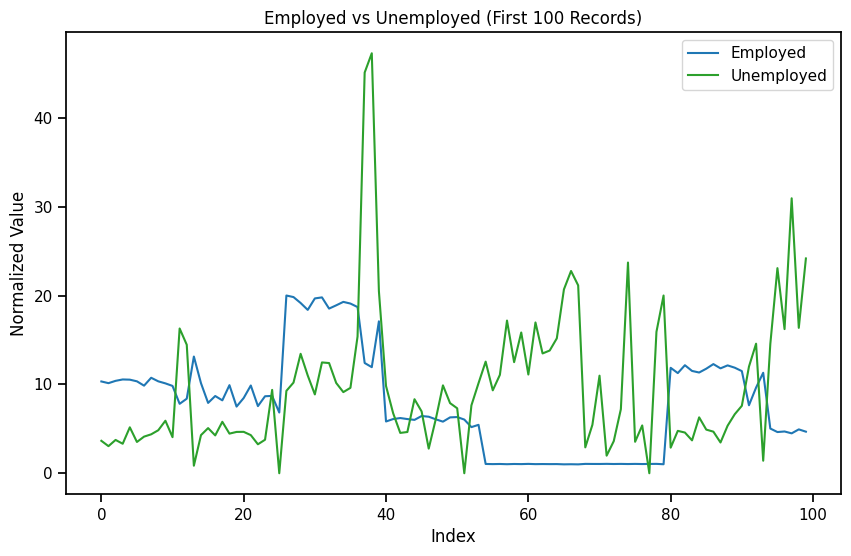

In [ ]:
# Plotting the first 100 records for demonstration
n = 100
Employed = india['Estimated Employed'].iloc[:n]
Unemployed = india['Estimated Unemployment Rate (%)'].iloc[:n]

Employed = (Employed - Employed.min())/(Employed.max() - Employed.min()) * 19 + 1

plt.figure(figsize=(10,6))
plt.plot(Employed, label='Employed', color='#1f77b4')
plt.plot(Unemployed, label='Unemployed', color='#2ca02c')
plt.legend()
plt.title('Employed vs Unemployed (First {} Records)'.format(n))
plt.xlabel('Index')
plt.ylabel('Normalized Value')
plt.show()

In [18]:
group = india.groupby(['Region','Area']).agg({'Estimated Unemployment Rate (%)': 'mean'})

In [19]:
group.style.bar(color="lightgreen")

In [20]:
india['Date'] = india['Date'].astype(str)
india[['Day','Month','Year']] = india['Date'].str.split('-', expand=True)
new_data = india.drop(['Date'],axis=1)
new_data

,Region,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Day,Month,Year
0,Andhra Pradesh,Monthly,3.65,11999139.0,43.24,Rural,2019,05,31
1,Andhra Pradesh,Monthly,3.05,11755881.0,42.05,Rural,2019,06,30
2,Andhra Pradesh,Monthly,3.75,12086707.0,43.50,Rural,2019,07,31
3,Andhra Pradesh,Monthly,3.32,12285693.0,43.97,Rural,2019,08,31
4,Andhra Pradesh,Monthly,5.17,12256762.0,44.68,Rural,2019,09,30
...,...,...,...,...,...,...,...,...,...
749,West Bengal,Monthly,7.55,10871168.0,44.09,Urban,2020,02,29
750,West Bengal,Monthly,6.67,10806105.0,43.34,Urban,2020,03,31
751,West Bengal,Monthly,15.63,9299466.0,41.20,Urban,2020,04,30
752,West Bengal,Monthly,15.22,9240903.0,40.67,Urban,2020,05,31


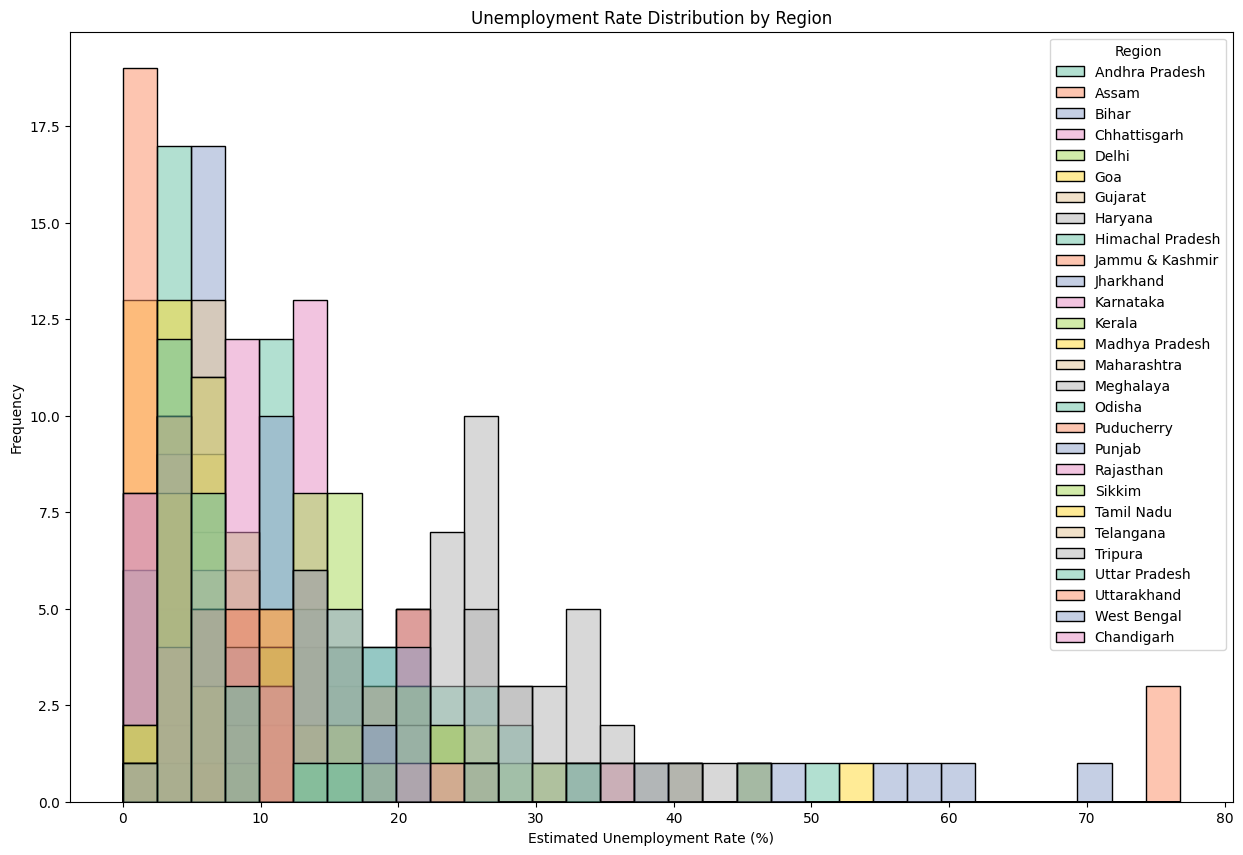

In [21]:
plt.figure(figsize=(15, 10))
plt.title("Unemployment Rate Distribution by Region")
sns.histplot(x="Estimated Unemployment Rate (%)", hue="Region", data=india, palette="Set2")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

In [22]:
region = india.groupby(["Region"])[['Estimated Unemployment Rate (%)', "Estimated Employed", "Estimated Labour Participation Rate (%)"]].mean()
region = pd.DataFrame(region).reset_index()

fig = px.bar(region, x="Region", y="Estimated Employed", color="Region", title="Average Employed Rate by Region", color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [29]:
unemployment = india[["Region", "Area", "Estimated Unemployment Rate (%)"]]

fig = px.sunburst(unemployment, path=['Area','Region'], values='Estimated Unemployment Rate (%)',
                  title='Unemployment rate in every State and Area', height=500, color='Region',
                  color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

## Conclusion

This analysis provided insights into unemployment trends in India, explored correlations between key employment metrics, and demonstrated best practices in data cleaning, validation, and visualization.


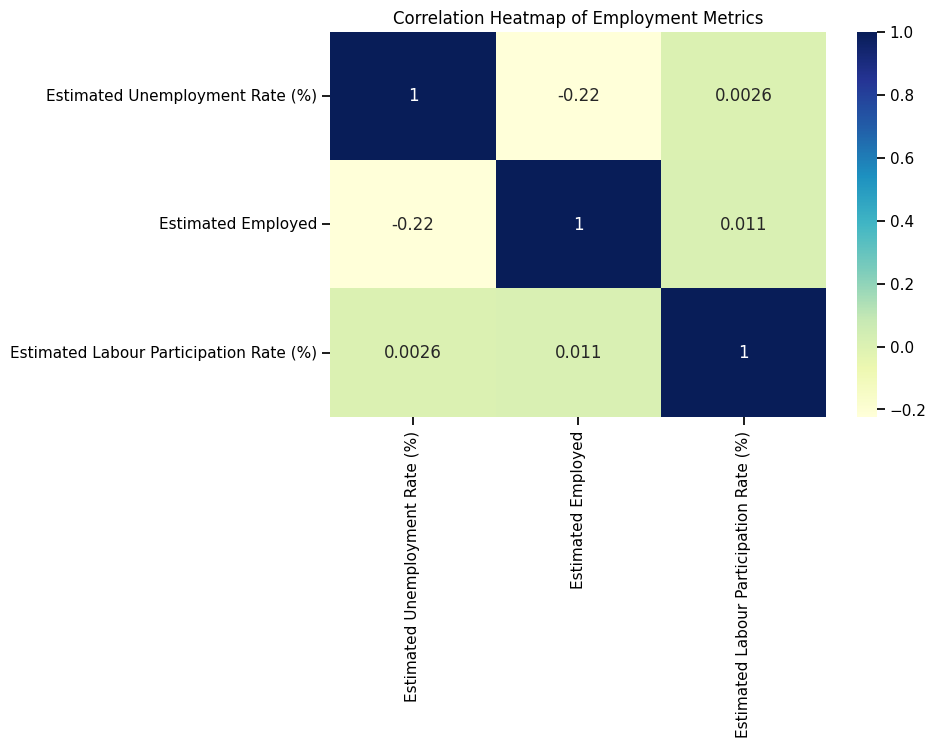

In [ ]:
heat_maps = india[['Estimated Unemployment Rate (%)','Estimated Employed','Estimated Labour Participation Rate (%)']]

heat_maps = heat_maps.corr()

plt.figure(figsize=(8,5))
sns.set_context('notebook', font_scale=1)
sns.heatmap(heat_maps, annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap of Employment Metrics')
plt.show()